Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
WhiteNoise -> 4

Validation Accuracy: 0.9420289855072463

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.97      0.97      0.97        69
  BrownNoise       0.88      0.88      0.88        69
       Clean       0.89      0.91      0.90        69
   PinkNoise       1.00      0.97      0.99        69
  WhiteNoise       0.97      0.97      0.97        69

    accuracy                           0.94       345
   macro avg       0.94      0.94      0.94       345
weighted avg       0.94      0.94      0.94       345


Confusion Matrix (Validation):
[[67  0  0  0  2]
 [ 0 61  8  0  0]
 [ 0  6 63  0  0]
 [ 0  2  0 67  0]
 [ 2  0  0  0 67]]

Unikke targets i test: [0 1 2 3 4]
Antal prøver pr. klasse: [100 100 100 100 100]

Test Accuracy: 0.958

Classification Report (Test):
              precision    recall  f1-score   support

   BlueNoise       0.98      0

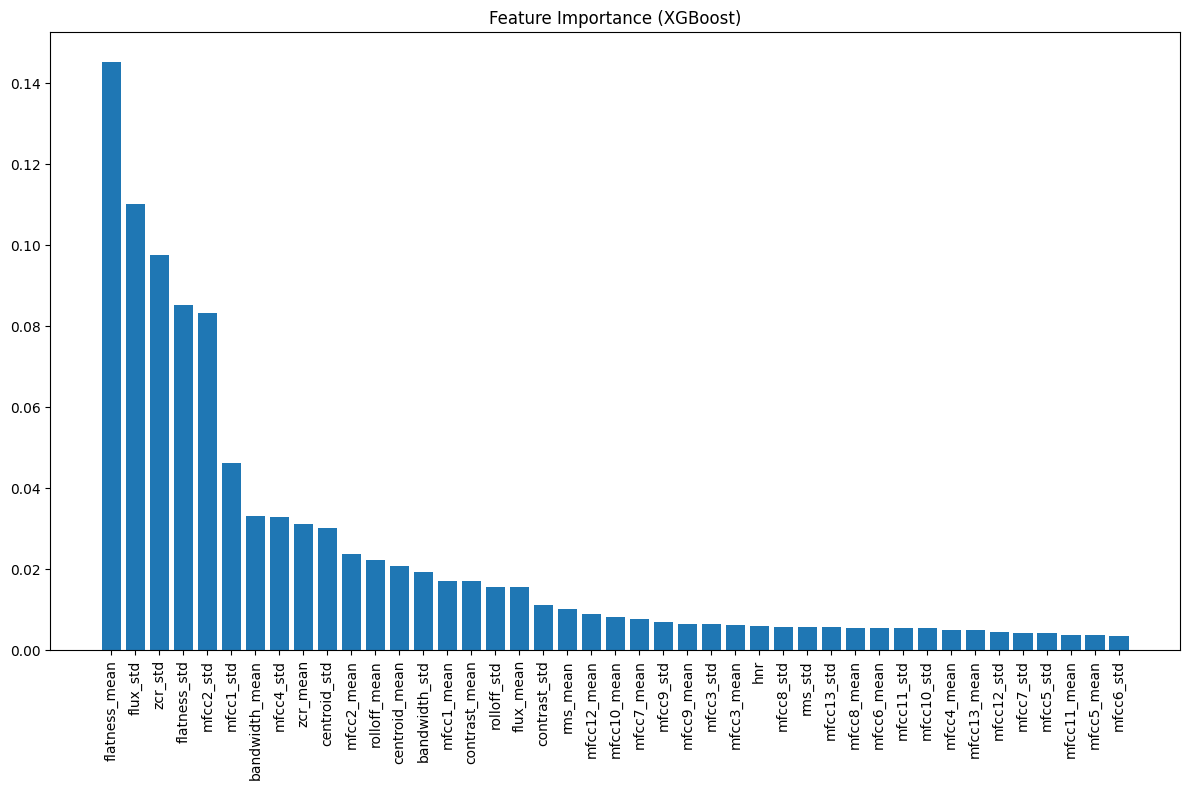


Top 15 vigtigste features:
flatness_mean: 0.1452
flux_std: 0.1102
zcr_std: 0.0976
flatness_std: 0.0853
mfcc2_std: 0.0833
mfcc1_std: 0.0462
bandwidth_mean: 0.0331
mfcc4_std: 0.0330
zcr_mean: 0.0312
centroid_std: 0.0303
mfcc2_mean: 0.0238
rolloff_mean: 0.0224
centroid_mean: 0.0209
bandwidth_std: 0.0193
mfcc1_mean: 0.0172


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "/Users/lasseleekrogshave/Desktop/Uni/Semester 2/Gruppeprojekt P2/New_Dataset/Speach_augmented/Training/audio_features_dataset_2026-03-06_15-09-50.csv"
df_train = pd.read_csv(train_path)

# Fjern VioletNoise filer
if "filnavn" in df_train.columns:
    df_train = df_train[~df_train["filnavn"].str.contains("VioletNoise", case=False, na=False)]

# Fjern irrelevant feature bagefter
if "filnavn" in df_train.columns:
    df_train = df_train.drop(columns=["filnavn"])


# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. XGBOOST MODEL
# ----------------------------
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. TEST ON SEPARATE DATASET
# ----------------------------
test_path = "/Users/lasseleekrogshave/Desktop/Uni/Semester 2/Gruppeprojekt P2/New_Dataset/Speach_augmented/Validation/audio_features_dataset_2026-03-06_15-19-52.csv"
df_test = pd.read_csv(test_path)

# Fjern VioletNoise filer
if "filnavn" in df_test.columns:
    df_test = df_test[~df_test["filnavn"].str.contains("VioletNoise", case=False, na=False)]

# Fjern irrelevant feature
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Split features og labels korrekt
X_test = df_test.drop(columns=["target"])
y_test_true = label_encoder.transform(df_test["target"])

# ---- HER PRINTER VI INFO OM TESTDATA ----
print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

# ----------------------------
# 7. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Print top 15 vigtigste features
print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")